# Random Forests Regression Implementation

## Overview

In this notebook, I applied **Random Forests** to predict Big Five personality traits (Extraversion, Agreeableness, Conscientiousness, Neuroticism, Openness) from textual life narrative responses (Q1–Q32).

### What is a Random Forest?

A **Random Forest** is an ensemble learning method that builds many decision trees during training and outputs the **average prediction** (regression) or **majority vote** (classification) across all trees.

Each tree is trained on:
- A **random bootstrap sample** of the data (bagging)
- A **random subset of features** at each split

This randomness makes the forest more robust and less prone to overfitting than a single decision tree.

### Why Random Forests for Personality Prediction?
- Handles high-dimensional TF-IDF text features well
- Robust to noisy features (many TF-IDF terms are irrelevant)
- Provides **feature importance** — tells us which words/phrases predict personality
- No need to scale features

### Pipeline
```
Raw narrative text (Q columns)
        ↓
TF-IDF Vectorization (text → numeric features)
        ↓
Random Forest Regressor (predict each Big Five trait)
        ↓
Evaluation (R², MAE, Cross-Validation)
        ↓
Feature Importance (which words matter most?)
```

## 1. Data preprocessing, import required packages

A reusable `RandomForestPersonality` class is defined:
- TF-IDF vectorization
- Random Forest training
- Cross-validation
- Evaluation metrics
- Feature importance plots

This mirrors how scikit-learn's own estimators work, making it easy to reuse across notebooks.

### Text Features (X)
All narrative columns are combined into a single text string per participant, then apply **TF-IDF** (Term Frequency–Inverse Document Frequency) to convert text into a numeric matrix.

- **TF (Term Frequency):** how often a word appears in a response
- **IDF (Inverse Document Frequency):** penalizes words that appear in almost every response (e.g., "the", "and")
- `max_features=500` keeps the 500 most informative words to avoid overfitting

### Targets (y)
Each Big Five trait score is a continuous variable (mean of item scores, scale 1–5), so this is a **regression** problem.

### Train/Test Split

Data is split into **80% training** and **20% testing**.

- The model learns patterns from the training set
- Performance is evaluated on the unseen test set
- `random_state=42` ensures reproducibility

In [50]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("../../src"))

from ml_models.randomforest import RandomForestPersonality

print("✓ Imports complete")

# Find repo root automatically
repo_root = Path.cwd().resolve()
while not (repo_root / "BFI_2_life_narative_metadata.json").exists():
    if repo_root == repo_root.parent:
        raise FileNotFoundError("Could not find BFI_2_life_narative_metadata.json")
    repo_root = repo_root.parent

# Load data
with open(repo_root / "BFI_2_life_narative_metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

with open(repo_root / "BFI_2_life_narrative.json", "r", encoding="utf-8") as f:
    responses = json.load(f)

df = pd.DataFrame(responses)

# Reverse-code BFI items
reverse_items = metadata["reverse_code_items"]

for item in reverse_items:
    if item in df.columns:
        df[item] = 6 - df[item]

# Big Five trait means
traits = {
    key: value
    for key, value in metadata.items()
    if (
        isinstance(value, list)
        and value
        and isinstance(value[0], str)
        and value[0].startswith("Item")
        and not key.startswith(("Item", "Q", "CWB", "OCB"))
        and key != "reverse_code_items"
    )
}

for trait, items in traits.items():
    available_items = [item for item in items if item in df.columns]
    df[trait] = df[available_items].mean(axis=1)

# CWB and OCB means
cwb_cols = [f"CWB{i}" for i in range(1, 11) if f"CWB{i}" in df.columns]
ocb_cols = [f"OCB{i}" for i in range(1, 11) if f"OCB{i}" in df.columns]

df["CWB"] = df[cwb_cols].mean(axis=1)
df["OCB"] = df[ocb_cols].mean(axis=1)

# Text features
q_cols = [c for c in df.columns if isinstance(c, str) and c.startswith("Q")]

X_text = df[q_cols].copy()
X_all = X_text.fillna("").agg(" ".join, axis=1)

# Targets
big_five = [
    "Extraversion",
    "Agreeableness",
    "Conscientiousness",
    "Neuroticism",
    "Openness",
]

y = df[big_five].copy()

print("✓ Data preprocessing complete")
print("Repo root:", repo_root)
print("df shape:", df.shape)
print("X_text shape:", X_text.shape)
print("X_all shape:", X_all.shape)
print(y.describe().round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

rf_model = RandomForestPersonality()

✓ Imports complete
✓ Data preprocessing complete
Repo root: /Users/cindy/cmor438_Spring2026/cmor438_Spring2026
df shape: (500, 138)
X_text shape: (500, 32)
X_all shape: (500,)
       Extraversion  Agreeableness  Conscientiousness  Neuroticism  Openness
count       500.000        500.000            500.000      500.000   500.000
mean          3.177          3.786              3.642        2.879     3.833
std           0.761          0.576              0.710        0.846     0.618
min           1.000          2.000              1.083        1.000     1.750
25%           2.667          3.417              3.167        2.333     3.417
50%           3.167          3.833              3.750        2.917     3.833
75%           3.750          4.167              4.083        3.417     4.250
max           5.000          5.000              5.000        4.917     5.000
Training samples : 400
Test samples     : 100


## 2. Hyperparameter Tuning with GridSearchCV

Before training the final model, **Grid Search with 5-fold Cross-Validation** was used to tune the key hyperparameters.

Hyperparameters are tuned on separately for each trait. As traits have different features, obtaining the best parameters for all traits can help optimize the overall prediction.

Key parameters to tune:
| Parameter | What it controls |
|---|---|
| `n_estimators` | More trees = more stable, slower |
| `max_depth` | Deeper = more complex, risk of overfitting |
| `min_samples_split` | Higher = simpler trees, less overfitting |

In [51]:
best_params = rf_model.tune(X_train, y_train)

best_params

{'Extraversion': {'n_estimators': 200,
  'max_depth': None,
  'min_samples_split': 2},
 'Agreeableness': {'n_estimators': 200,
  'max_depth': None,
  'min_samples_split': 5},
 'Conscientiousness': {'n_estimators': 200,
  'max_depth': 20,
  'min_samples_split': 5},
 'Neuroticism': {'n_estimators': 200,
  'max_depth': None,
  'min_samples_split': 5},
 'Openness': {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5}}

## 3. Train & Test Model

The full `RandomForestPersonality` model on all five traits is trained on the best parameters found above

Model is evaluated based on three metrics:

- **R² (coefficient of determination):** proportion of variance explained. R²=1 is perfect, R²=0 means the model is no better than predicting the mean. Negative R² means it's worse than the mean.
- **MAE (Mean Absolute Error):** average prediction error in the original scale (1–5). Lower is better.
- **Pearson's r:** correlation coefficient between predicted and actual values. Higher is better.

In [52]:
rf_model.fit(X_train, y_train)
rf_results = rf_model.evaluate(X_test, y_test)
print("Test Set Performance:")
rf_results

Test Set Performance:


,R²,MAE,Pearson r
Trait,,,
Extraversion,0.0571,0.6022,0.2644
Agreeableness,-0.0381,0.4111,0.0859
Conscientiousness,0.0895,0.5761,0.3153
Neuroticism,0.0480,0.7280,0.2562
Openness,-0.0215,0.5452,0.0672


## 4. 5-fold Cross Validation

To ensure the stability of the results, 5-fold CV is applied.

In [53]:
cv_results = rf_model.cross_validate(X_all, y)
cv_results

,CV Mean R²,CV Std R²,CV MAE,Pearson r
Trait,,,,
Extraversion,0.0723,0.0057,0.5837,0.2981
Agreeableness,-0.0393,0.0178,0.4639,0.0296
Conscientiousness,0.0757,0.0303,0.5456,0.2916
Neuroticism,0.0566,0.0223,0.6548,0.2601
Openness,0.0141,0.0240,0.4922,0.1396


## 5. Plot feature importance

To better understand what the model is learning, the top 15 most important words for each trait based on the Random Forest feature importance scores are plotted. This enabled moving beyond overall prediction performance and examine the specific linguistic patterns associated with each trait. By visualizing these influential features, we can identify meaningful trends in how different word usages contribute to personality predictions, providing interpretability and insight into the underlying text–trait relationships.

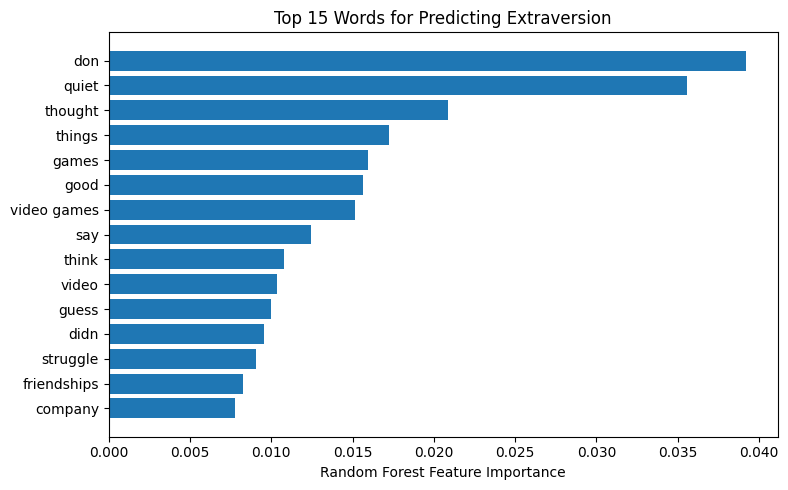

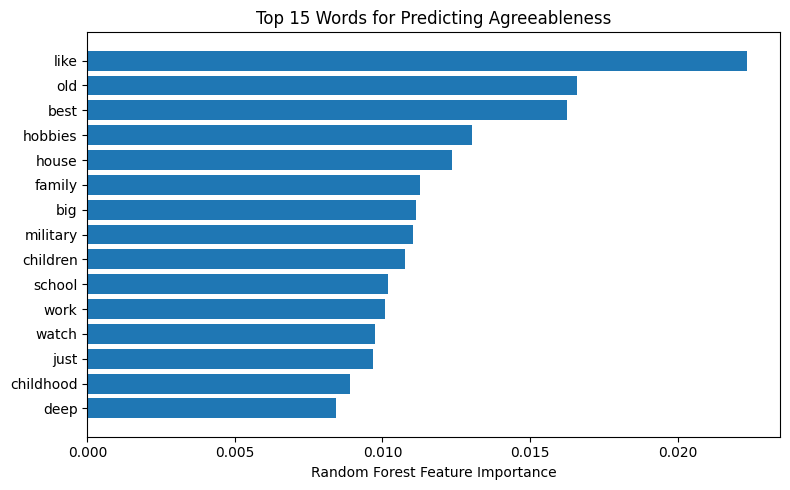

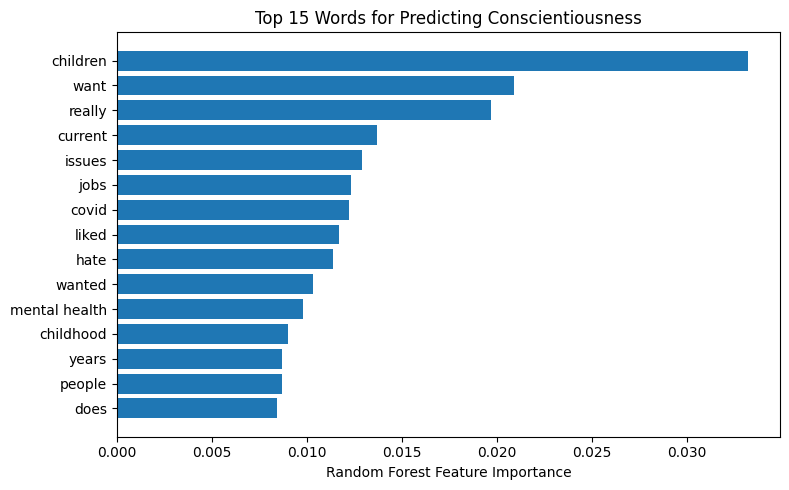

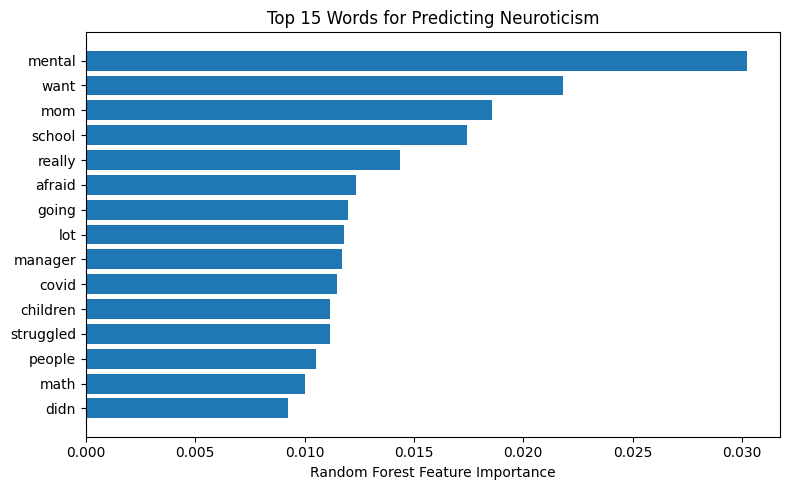

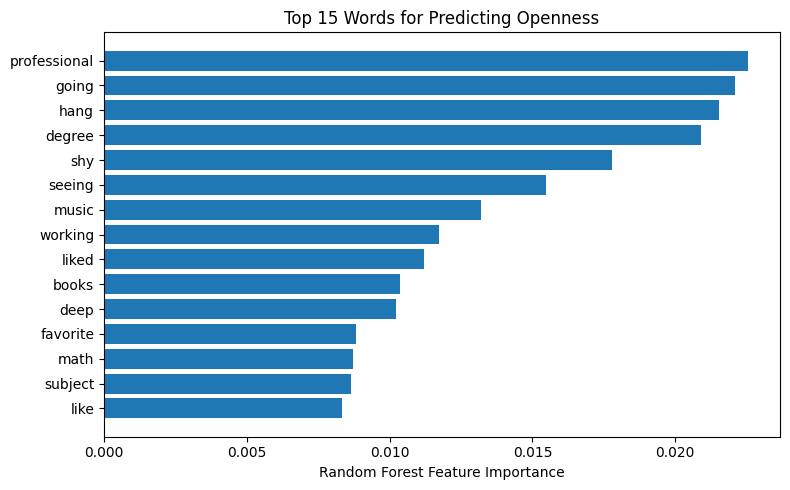

In [54]:
for trait in big_five:
    rf_model.plot_feature_importance(trait, top_n=15)

## Results analysis 

### Pearson's r Results 

| Trait | Pearson's r |
| --- | ---: |
| Extraversion | `0.298` |
| Agreeableness | `0.030` |
| Conscientiousness | `0.292` |
| Neuroticism | `0.260` |
| Openness | `0.140` |

Random Forest presents best prediction performance for extraversion, conscientiousness and neuroticism, with a weak to moderate convergent validity.

### Key Findings

#### 1. Extraversion Was the Best Predicted Trait

Extraversion had the highest Pearson's r (`0.298`) and one of the strongest R² values. This suggests that narrative responses contain useful cues about sociability, activity preferences, and interpersonal orientation.

Important words included:

- quiet
- friendships
- company
- games
- video games

These likely reflect differences in social engagement and lifestyle.

#### 2. Conscientiousness Was Also Predictable

Conscientiousness performed similarly well (`r = 0.292`), suggesting writing style and content may reveal responsibility, planning, and self-regulation.

Important words included:

- currently
- jobs
- years
- wanted
- issues

These may capture structured thinking, goal orientation, and life management themes.

#### 3. Neuroticism Showed Meaningful Emotional Signal

Neuroticism had a weak but meaningful correlation (`r = 0.260`).

Important words included:

- mental
- afraid
- struggled
- school
- mom

These suggest emotional stress, anxiety, and personal challenges may appear in narrative language.

#### 4. Openness Was Harder to Predict

Openness showed only a very weak relationship (`r = 0.140`).

Important words included:

- music
- books
- degree
- subject
- professional

These words conceptually align with curiosity and intellectual interests, but the predictive signal was limited.

#### 5. Agreeableness Was the Hardest Trait to Capture

Agreeableness had near-zero correlation (`r = 0.030`) and negative R², meaning the model did not meaningfully predict this trait.

Although some family/community words appeared important:

- family
- children
- school
- hobbies

the trait may require deeper context, tone, or interaction-based data rather than isolated word frequencies.